# Phase 3 — Final Test Evaluation & E-Improvement Analysis

Compares three approaches on the **held-out test set** (n=288, never seen during prompt tuning):
- **v1**: Original winner (`trait_first`, 11-shot, temp 0.3, original exemplars)
- **v2**: E-improved (`trait_first_v2`, rebalanced exemplars + E-calibration guards in prompt)
- **v1+cal**: v1 predictions with post-hoc linear E calibration (fitted on dev)

Baseline: mean Pearson r = 0.457 (N8N, 7-shot)

In [1]:
import json
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob as g

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12, "axes.labelsize": 10})

TRAITS = ["O", "C", "E", "A", "N"]
TRAIT_NAMES = {"O": "Openness", "C": "Conscientiousness", "E": "Extraversion", "A": "Agreeableness", "N": "Neuroticism"}
BASELINE_R = 0.457
PHASE3_RESULTS = Path("../phase3/results")
HARNESS_RESULTS = Path("../results")

In [2]:
# Load results
def load_results(base_dir, pattern):
    rows = []
    for fp in sorted(base_dir.glob(pattern)):
        for line in open(fp):
            r = json.loads(line.strip())
            if r.get("detected_ocean"):
                rows.append(r)
    seen = {}
    for r in rows:
        seen[r["sample_id"]] = r
    return list(seen.values())

v1_test = load_results(PHASE3_RESULTS, "phase3_v1_test_*.jsonl")
v2_test = load_results(PHASE3_RESULTS, "phase3_v2_test_*.jsonl")
v2_dev  = load_results(PHASE3_RESULTS, "phase3_v2_dev_*.jsonl")

# v1 dev predictions (from Phase 1 harness) for calibration fitting
v1_dev = load_results(HARNESS_RESULTS, "harness_trait_first_s11_t03*.jsonl")

print(f"v1 test: {len(v1_test)}")
print(f"v2 test: {len(v2_test)}")
print(f"v2 dev:  {len(v2_dev)}")
print(f"v1 dev:  {len(v1_dev)}")

v1 test: 288
v2 test: 288
v2 dev:  80
v1 dev:  80


In [3]:
# Fit E calibration on v1 dev predictions
e_pred_dev = np.array([r["detected_ocean"]["E"] for r in v1_dev if "E" in r.get("ground_truth_ocean", {})])
e_gt_dev = np.array([r["ground_truth_ocean"]["E"] for r in v1_dev if "E" in r.get("ground_truth_ocean", {})])

slope, intercept, _, _, _ = stats.linregress(e_pred_dev, e_gt_dev)
print(f"E calibration:  calibrated_E = {slope:.4f} * pred_E + ({intercept:+.4f})")
print(f"Dev fit — r_before={stats.pearsonr(e_pred_dev, e_gt_dev)[0]:.3f}, bias={np.mean(e_pred_dev - e_gt_dev):+.3f}")
cal_dev = np.clip(slope * e_pred_dev + intercept, -1, 1)
print(f"Dev fit — r_after ={stats.pearsonr(cal_dev, e_gt_dev)[0]:.3f}, bias={np.mean(cal_dev - e_gt_dev):+.3f}")

E calibration:  calibrated_E = 0.6521 * pred_E + (-0.0172)
Dev fit — r_before=0.461, bias=+0.213
Dev fit — r_after =0.461, bias=+0.000


In [4]:
# Compute metrics for all three approaches
def compute_metrics(rows, e_calibration=None):
    results = {}
    for t in TRAITS:
        pairs = [(r["detected_ocean"][t], r["ground_truth_ocean"][t])
                 for r in rows if t in r.get("ground_truth_ocean", {}) and t in r.get("detected_ocean", {})]
        if len(pairs) < 5:
            continue
        pred = np.array([p[0] for p in pairs])
        gt = np.array([p[1] for p in pairs])
        if t == "E" and e_calibration is not None:
            pred = np.clip(e_calibration[0] * pred + e_calibration[1], -1, 1)
        r_val, p_val = stats.pearsonr(pred, gt)
        results[t] = {"r": r_val, "mae": np.mean(np.abs(pred - gt)),
                      "bias": np.mean(pred - gt), "n": len(pairs),
                      "pred": pred, "gt": gt}
    results["macro_r"] = np.mean([results[t]["r"] for t in TRAITS if t in results])
    results["macro_mae"] = np.mean([results[t]["mae"] for t in TRAITS if t in results])
    return results

m_v1  = compute_metrics(v1_test)
m_v2  = compute_metrics(v2_test)
m_cal = compute_metrics(v1_test, e_calibration=(slope, intercept))

# Summary table
rows_t = []
for label, m in [("v1 original", m_v1), ("v2 E-improved", m_v2), ("v1+calibration", m_cal)]:
    row = {"Approach": label, "macro_r": round(m["macro_r"], 3), "macro_MAE": round(m["macro_mae"], 3)}
    for t in TRAITS:
        if t in m:
            row[f"r_{t}"] = round(m[t]["r"], 3)
            row[f"bias_{t}"] = round(m[t]["bias"], 3)
    rows_t.append(row)

summary = pd.DataFrame(rows_t).set_index("Approach")
display(summary)

,macro_r,macro_MAE,r_O,bias_O,r_C,bias_C,r_E,bias_E,r_A,bias_A,r_N,bias_N
Approach,,,,,,,,,,,,
v1 original,0.466,0.383,0.354,0.101,0.426,0.210,0.486,0.296,0.552,0.057,0.514,0.107
v2 E-improved,0.457,0.386,0.294,0.151,0.367,0.148,0.560,0.144,0.564,0.089,0.499,0.099
v1+calibration,0.466,0.370,0.354,0.101,0.426,0.210,0.486,0.098,0.552,0.057,0.514,0.107


In [5]:
# Dev vs Test generalization gap
print("Dev (Phase 1) vs Test (Phase 3) — v1 original:")
print(f"  Dev  macro r = 0.661  (n=80, optimized on this set)")
print(f"  Test macro r = {m_v1['macro_r']:.3f}  (n={len(v1_test)}, held-out)")
print(f"  Gap: {m_v1['macro_r'] - 0.661:+.3f} ({(m_v1['macro_r'] - 0.661)/0.661*100:+.1f}%)")
print()
print("Per-trait generalization gap (v1):")
dev_rs = {"O": 0.563, "C": 0.655, "E": 0.461, "A": 0.824, "N": 0.801}
for t in TRAITS:
    if t in m_v1:
        gap = m_v1[t]["r"] - dev_rs[t]
        print(f"  {TRAIT_NAMES[t]:<20s}  dev={dev_rs[t]:.3f}  test={m_v1[t]['r']:.3f}  gap={gap:+.3f}")

Dev (Phase 1) vs Test (Phase 3) — v1 original:
  Dev  macro r = 0.661  (n=80, optimized on this set)
  Test macro r = 0.466  (n=288, held-out)
  Gap: -0.195 (-29.5%)

Per-trait generalization gap (v1):
  Openness              dev=0.563  test=0.354  gap=-0.209
  Conscientiousness     dev=0.655  test=0.426  gap=-0.229
  Extraversion          dev=0.461  test=0.486  gap=+0.025
  Agreeableness         dev=0.824  test=0.552  gap=-0.272
  Neuroticism           dev=0.801  test=0.514  gap=-0.287


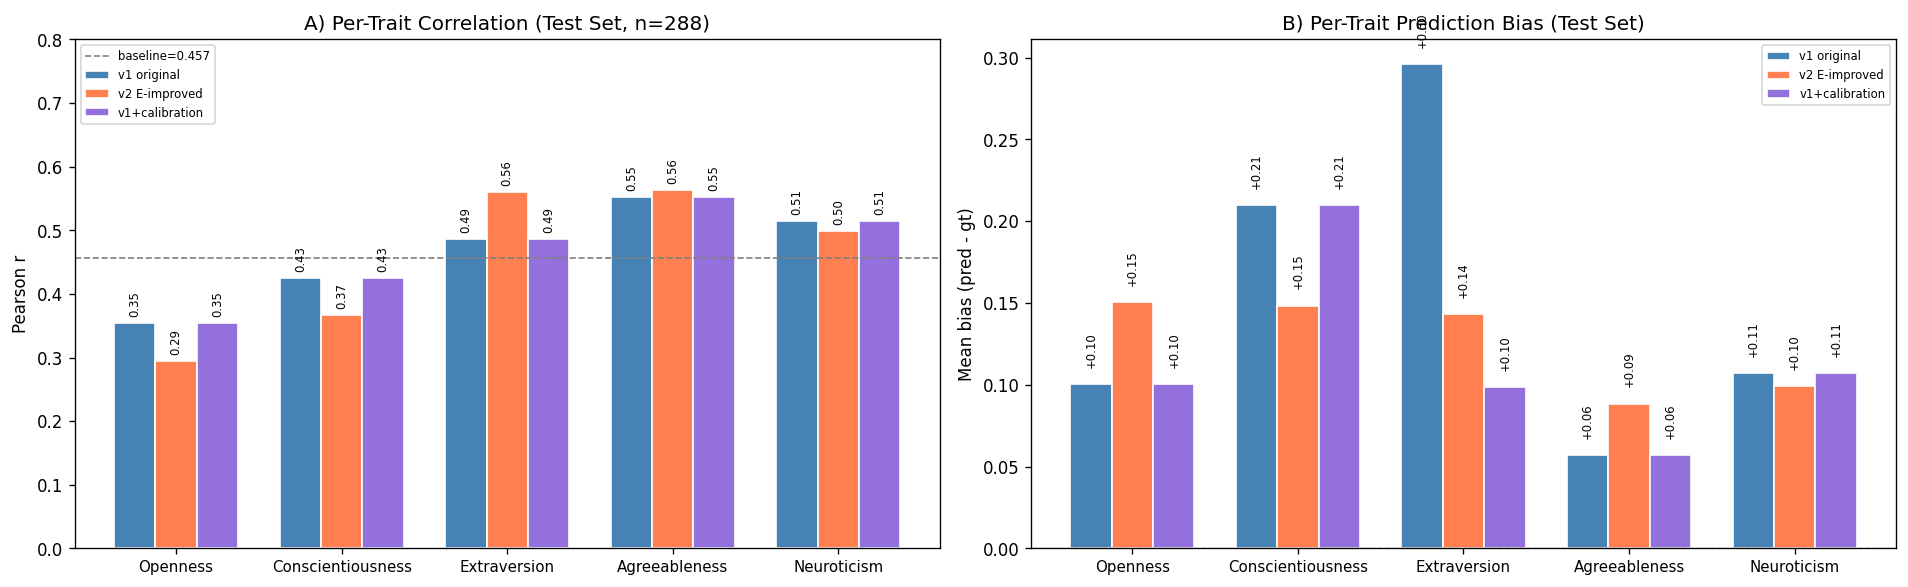

In [6]:
# Grouped bar chart: r and bias for all 3 approaches
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(5)
w = 0.25

# Panel A: Pearson r
ax = axes[0]
for i, (label, m, color) in enumerate([
    ("v1 original", m_v1, "steelblue"),
    ("v2 E-improved", m_v2, "coral"),
    ("v1+calibration", m_cal, "mediumpurple")]):
    vals = [m[t]["r"] if t in m else 0 for t in TRAITS]
    bars = ax.bar(x + i*w - w, vals, w, label=label, color=color, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=7, rotation=90, va="bottom")
ax.axhline(BASELINE_R, color="gray", ls="--", lw=1, label=f"baseline={BASELINE_R}")
ax.set_xticks(x)
ax.set_xticklabels([TRAIT_NAMES[t] for t in TRAITS], fontsize=9)
ax.set_ylabel("Pearson r")
ax.set_title("A) Per-Trait Correlation (Test Set, n=288)")
ax.legend(fontsize=7, loc="upper left")
ax.set_ylim(0, 0.8)

# Panel B: Bias
ax = axes[1]
for i, (label, m, color) in enumerate([
    ("v1 original", m_v1, "steelblue"),
    ("v2 E-improved", m_v2, "coral"),
    ("v1+calibration", m_cal, "mediumpurple")]):
    vals = [m[t]["bias"] if t in m else 0 for t in TRAITS]
    bars = ax.bar(x + i*w - w, vals, w, label=label, color=color, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01 * np.sign(v), f"{v:+.2f}", ha="center",
                fontsize=7, rotation=90, va="bottom" if v >= 0 else "top")
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([TRAIT_NAMES[t] for t in TRAITS], fontsize=9)
ax.set_ylabel("Mean bias (pred - gt)")
ax.set_title("B) Per-Trait Prediction Bias (Test Set)")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

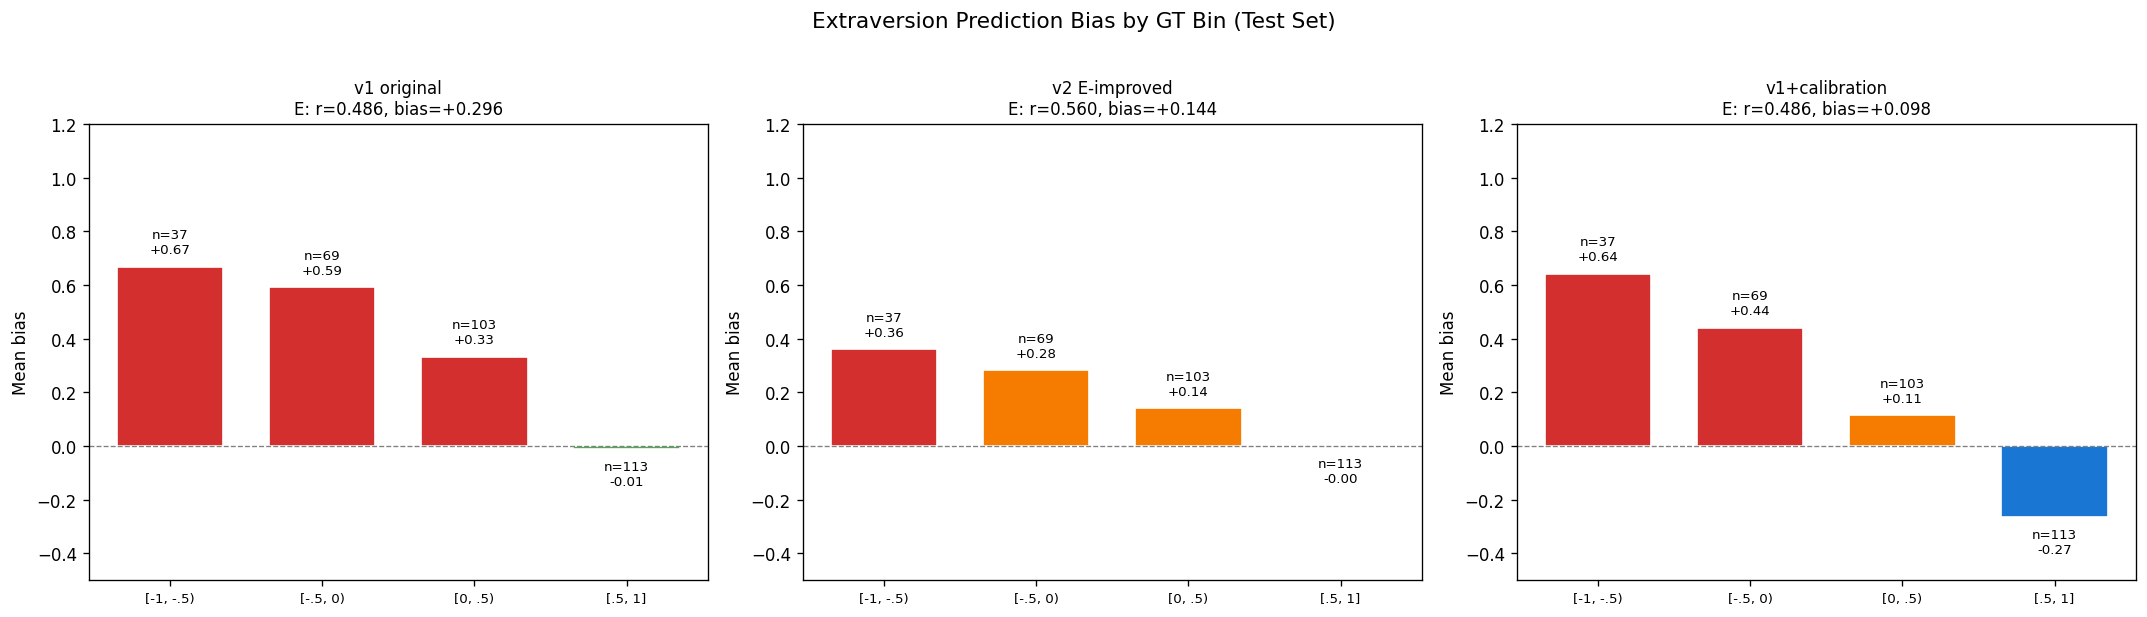

In [7]:
# E-specific deep dive: bias by GT bin for all 3 approaches
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bins_edges = [(-1.0, -0.5), (-0.5, 0.0), (0.0, 0.5), (0.5, 1.0)]
bin_labels = ["[-1, -.5)", "[-.5, 0)", "[0, .5)", "[.5, 1]"]

for ax, (label, m, color) in zip(axes, [
    ("v1 original", m_v1, "steelblue"),
    ("v2 E-improved", m_v2, "coral"),
    ("v1+calibration", m_cal, "mediumpurple")]):
    if "E" not in m:
        continue
    pred, gt = m["E"]["pred"], m["E"]["gt"]
    biases, counts = [], []
    for lo, hi in bins_edges:
        mask = (gt >= lo) & (gt < hi + 0.01)
        if mask.sum() >= 2:
            biases.append((pred[mask] - gt[mask]).mean())
            counts.append(mask.sum())
        else:
            biases.append(0)
            counts.append(0)
    bar_colors = ["#d32f2f" if b > 0.3 else "#f57c00" if b > 0.1 else "#4caf50" if abs(b) <= 0.1 else "#1976d2" for b in biases]
    bars = ax.bar(range(4), biases, color=bar_colors, edgecolor="white", width=0.7)
    ax.set_xticks(range(4))
    ax.set_xticklabels(bin_labels, fontsize=8)
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_ylim(-0.5, 1.2)
    ax.set_title(f"{label}\nE: r={m['E']['r']:.3f}, bias={m['E']['bias']:+.3f}", fontsize=10)
    ax.set_ylabel("Mean bias")
    for i, (b, n) in enumerate(zip(biases, counts)):
        ax.text(i, b + 0.04 * np.sign(b) if b != 0 else 0.04, f"n={n}\n{b:+.2f}", ha="center", fontsize=8,
                va="bottom" if b >= 0 else "top")

fig.suptitle("Extraversion Prediction Bias by GT Bin (Test Set)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

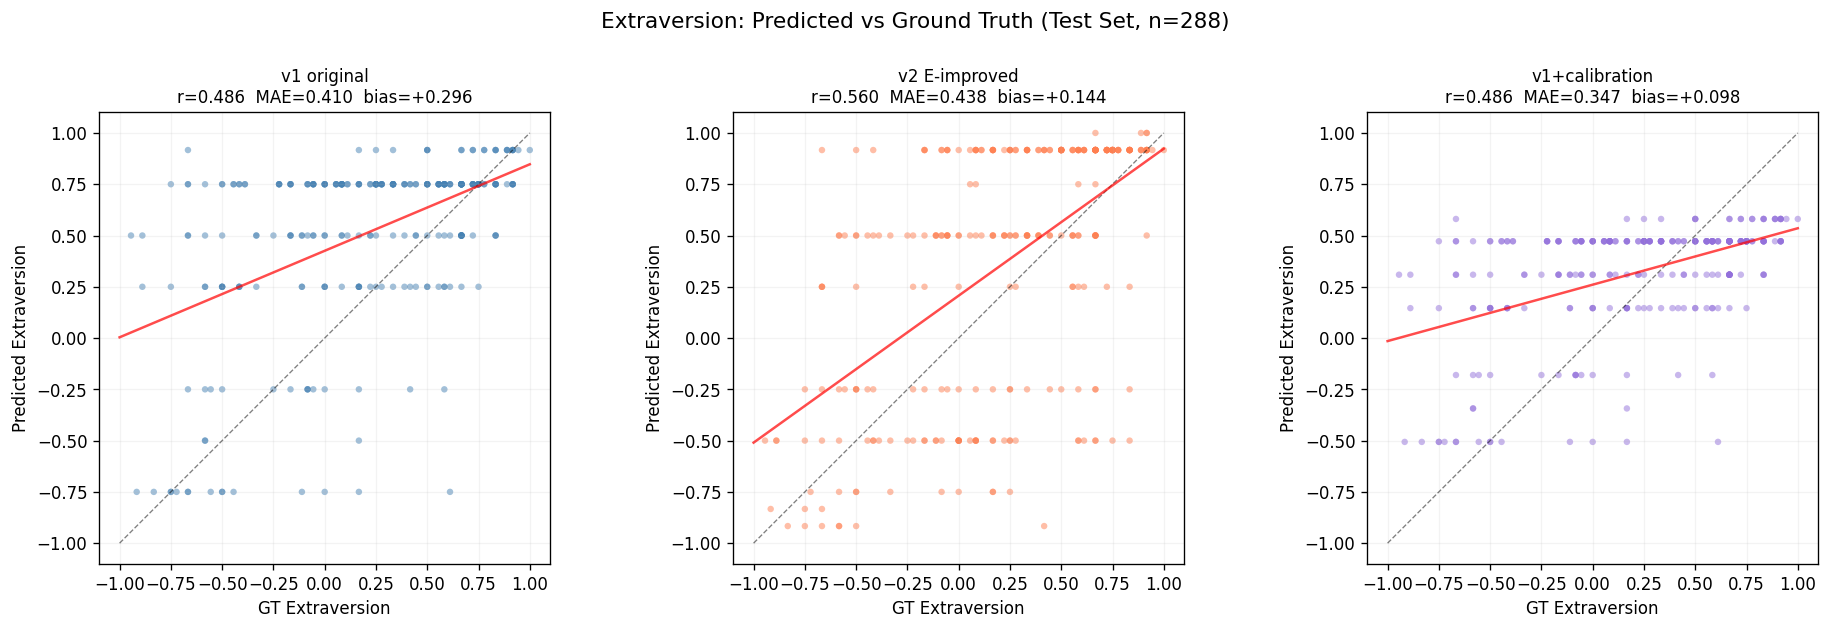

In [8]:
# Scatter: predicted vs GT for Extraversion — 3 approaches side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, m, color) in zip(axes, [
    ("v1 original", m_v1, "steelblue"),
    ("v2 E-improved", m_v2, "coral"),
    ("v1+calibration", m_cal, "mediumpurple")]):
    if "E" not in m:
        continue
    pred, gt = m["E"]["pred"], m["E"]["gt"]
    ax.scatter(gt, pred, s=15, alpha=0.5, color=color, edgecolors="none")
    ax.plot([-1, 1], [-1, 1], "k--", lw=0.8, alpha=0.5)
    z = np.polyfit(gt, pred, 1)
    x_fit = np.linspace(-1, 1, 100)
    ax.plot(x_fit, np.polyval(z, x_fit), color="red", lw=1.5, alpha=0.7, ls="-")
    ax.set_xlabel("GT Extraversion")
    ax.set_ylabel("Predicted Extraversion")
    ax.set_title(f"{label}\nr={m['E']['r']:.3f}  MAE={m['E']['mae']:.3f}  bias={m['E']['bias']:+.3f}", fontsize=10)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")
    ax.grid(alpha=0.15)

fig.suptitle("Extraversion: Predicted vs Ground Truth (Test Set, n=288)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

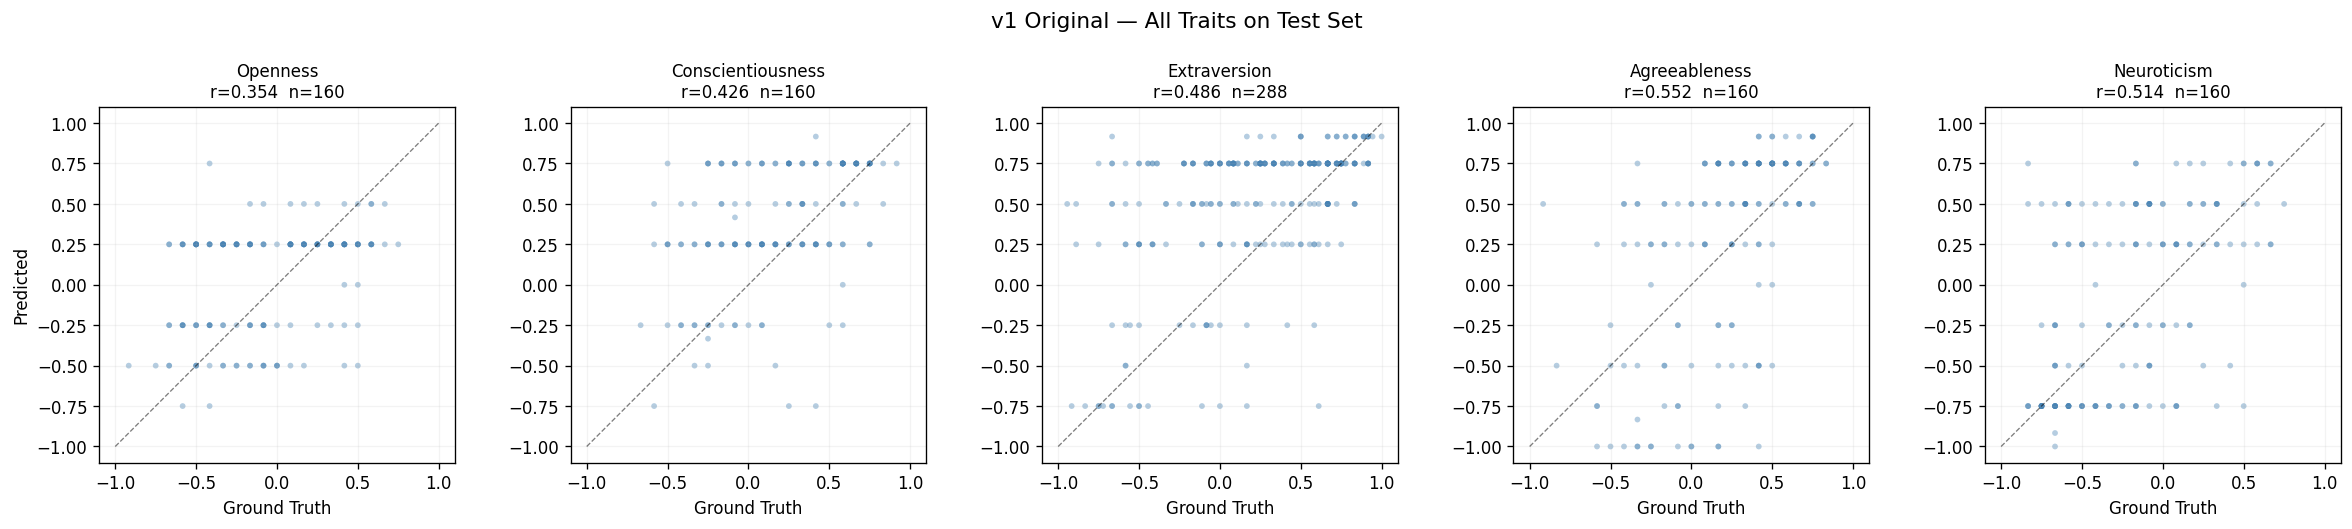

In [9]:
# Full 5-trait scatter for v1 (best macro r)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, t in zip(axes, TRAITS):
    if t not in m_v1:
        continue
    pred, gt = m_v1[t]["pred"], m_v1[t]["gt"]
    ax.scatter(gt, pred, s=12, alpha=0.4, color="steelblue", edgecolors="none")
    ax.plot([-1, 1], [-1, 1], "k--", lw=0.8, alpha=0.5)
    ax.set_xlabel("Ground Truth")
    if t == "O":
        ax.set_ylabel("Predicted")
    ax.set_title(f"{TRAIT_NAMES[t]}\nr={m_v1[t]['r']:.3f}  n={m_v1[t]['n']}", fontsize=10)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")
    ax.grid(alpha=0.15)

fig.suptitle("v1 Original — All Traits on Test Set", fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

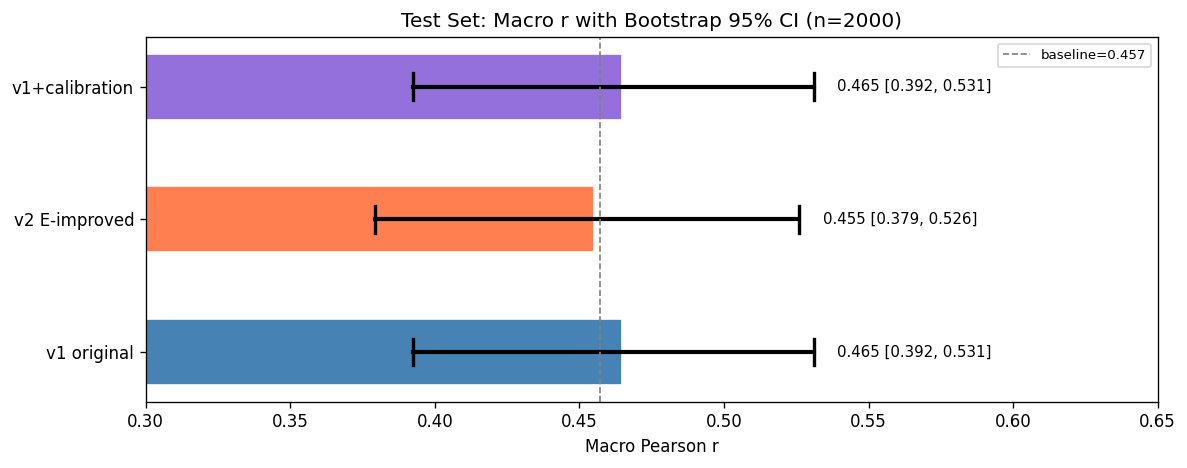

In [10]:
# Bootstrap 95% CIs
def bootstrap_macro_r(rows, n_boot=2000, e_cal=None, seed=42):
    rng = np.random.RandomState(seed)
    macro_rs = []
    for _ in range(n_boot):
        idx = rng.choice(len(rows), len(rows), replace=True)
        sampled = [rows[i] for i in idx]
        trait_rs = []
        for t in TRAITS:
            pairs = [(r["detected_ocean"][t], r["ground_truth_ocean"][t])
                     for r in sampled if t in r.get("ground_truth_ocean", {}) and t in r.get("detected_ocean", {})]
            if len(pairs) < 5:
                continue
            p = np.array([x[0] for x in pairs])
            gg = np.array([x[1] for x in pairs])
            if t == "E" and e_cal is not None:
                p = np.clip(e_cal[0] * p + e_cal[1], -1, 1)
            if np.std(p) < 1e-9 or np.std(gg) < 1e-9:
                continue
            r_val, _ = stats.pearsonr(p, gg)
            trait_rs.append(r_val)
        if trait_rs:
            macro_rs.append(np.mean(trait_rs))
    return np.array(macro_rs)

boot_v1  = bootstrap_macro_r(v1_test)
boot_v2  = bootstrap_macro_r(v2_test)
boot_cal = bootstrap_macro_r(v1_test, e_cal=(slope, intercept))

fig, ax = plt.subplots(figsize=(10, 4))
for i, (label, boot, color) in enumerate([
    ("v1 original", boot_v1, "steelblue"),
    ("v2 E-improved", boot_v2, "coral"),
    ("v1+calibration", boot_cal, "mediumpurple")]):
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    mean = boot.mean()
    ax.barh(i, mean, color=color, edgecolor="white", height=0.5)
    ax.plot([ci_lo, ci_hi], [i, i], color="black", lw=2.5)
    ax.plot([ci_lo, ci_lo], [i-0.1, i+0.1], color="black", lw=2)
    ax.plot([ci_hi, ci_hi], [i-0.1, i+0.1], color="black", lw=2)
    ax.text(ci_hi + 0.008, i, f"{mean:.3f} [{ci_lo:.3f}, {ci_hi:.3f}]", va="center", fontsize=9)

ax.axvline(BASELINE_R, color="gray", ls="--", lw=1, label=f"baseline={BASELINE_R}")
ax.set_yticks(range(3))
ax.set_yticklabels(["v1 original", "v2 E-improved", "v1+calibration"])
ax.set_xlabel("Macro Pearson r")
ax.set_title("Test Set: Macro r with Bootstrap 95% CI (n=2000)")
ax.legend(fontsize=8)
ax.set_xlim(0.3, 0.65)
plt.tight_layout()
plt.show()

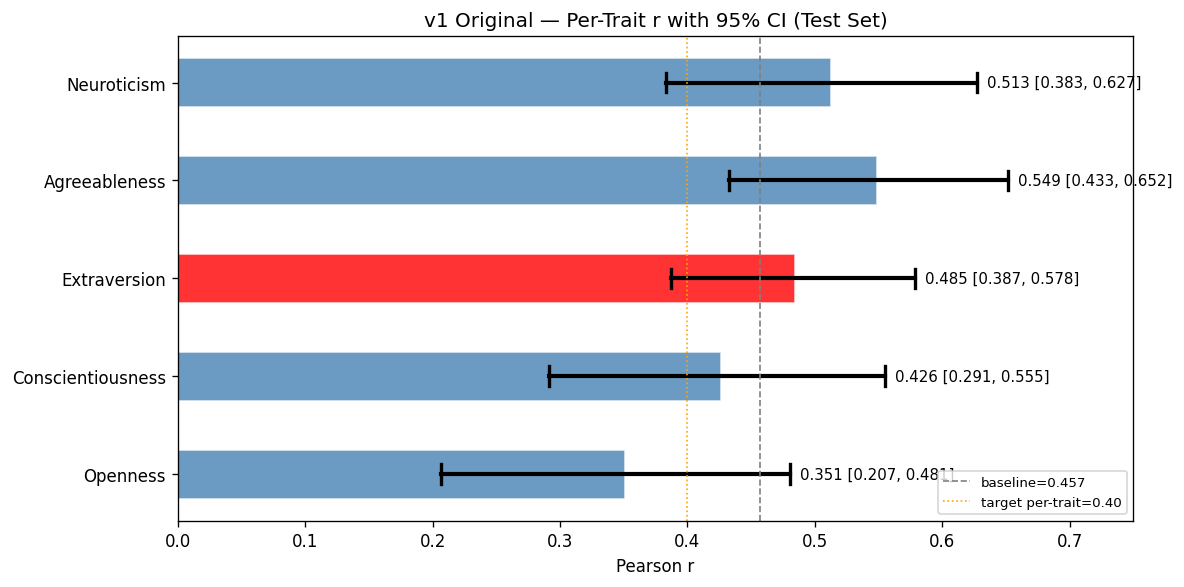

In [11]:
# Per-trait bootstrap CIs for the best approach (v1)
def bootstrap_per_trait(rows, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    results = {t: [] for t in TRAITS}
    for _ in range(n_boot):
        idx = rng.choice(len(rows), len(rows), replace=True)
        sampled = [rows[i] for i in idx]
        for t in TRAITS:
            pairs = [(r["detected_ocean"][t], r["ground_truth_ocean"][t])
                     for r in sampled if t in r.get("ground_truth_ocean", {}) and t in r.get("detected_ocean", {})]
            if len(pairs) < 5:
                continue
            p = np.array([x[0] for x in pairs])
            gg = np.array([x[1] for x in pairs])
            if np.std(p) < 1e-9 or np.std(gg) < 1e-9:
                continue
            r_val, _ = stats.pearsonr(p, gg)
            results[t].append(r_val)
    return {t: np.array(v) for t, v in results.items()}

trait_boots = bootstrap_per_trait(v1_test)

fig, ax = plt.subplots(figsize=(10, 5))
for i, t in enumerate(TRAITS):
    boot = trait_boots[t]
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    mean = boot.mean()
    color = "red" if t == "E" else "steelblue"
    ax.barh(i, mean, color=color, edgecolor="white", height=0.5, alpha=0.8)
    ax.plot([ci_lo, ci_hi], [i, i], color="black", lw=2.5)
    ax.plot([ci_lo, ci_lo], [i-0.1, i+0.1], color="black", lw=2)
    ax.plot([ci_hi, ci_hi], [i-0.1, i+0.1], color="black", lw=2)
    ax.text(ci_hi + 0.008, i, f"{mean:.3f} [{ci_lo:.3f}, {ci_hi:.3f}]", va="center", fontsize=9)

ax.axvline(BASELINE_R, color="gray", ls="--", lw=1, label=f"baseline={BASELINE_R}")
ax.axvline(0.40, color="orange", ls=":", lw=1, label="target per-trait=0.40")
ax.set_yticks(range(5))
ax.set_yticklabels([TRAIT_NAMES[t] for t in TRAITS])
ax.set_xlabel("Pearson r")
ax.set_title("v1 Original — Per-Trait r with 95% CI (Test Set)")
ax.legend(fontsize=8)
ax.set_xlim(0, 0.75)
plt.tight_layout()
plt.show()

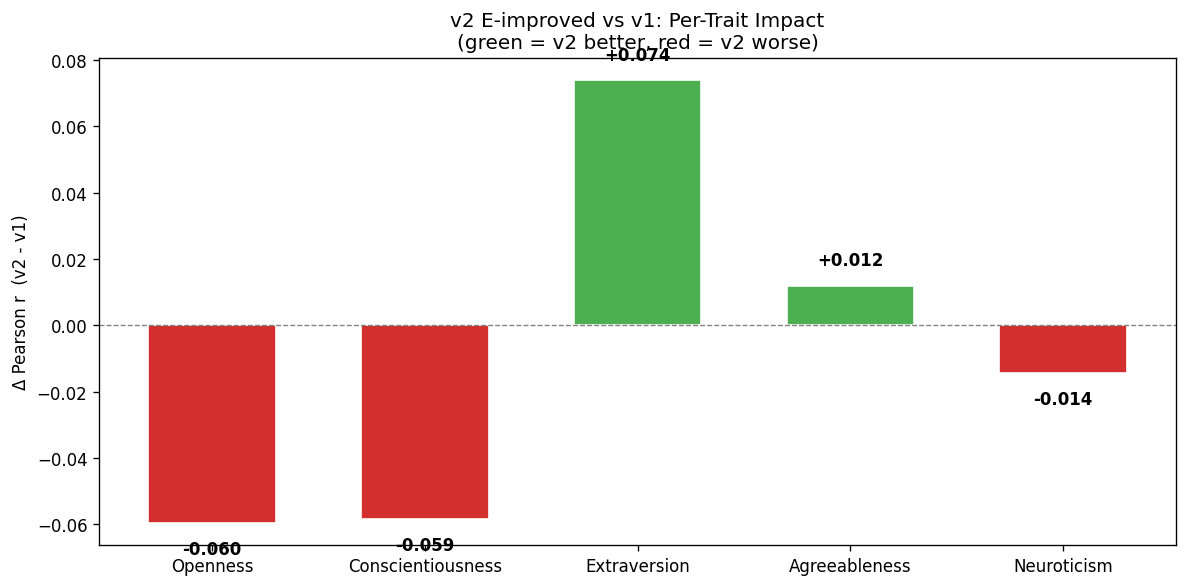

v2 gains on E: +0.074 and A: +0.012
v2 loses on O: -0.060 and C: -0.059 (exemplar rebalancing cost)


In [12]:
# v1 vs v2 trait-level comparison: where v2 wins vs loses
fig, ax = plt.subplots(figsize=(10, 5))

deltas = []
for t in TRAITS:
    d = m_v2[t]["r"] - m_v1[t]["r"] if t in m_v2 and t in m_v1 else 0
    deltas.append(d)

colors = ["#4caf50" if d > 0 else "#d32f2f" for d in deltas]
bars = ax.bar([TRAIT_NAMES[t] for t in TRAITS], deltas, color=colors, edgecolor="white", width=0.6)
ax.axhline(0, color="gray", ls="--", lw=0.8)
for bar, d, t in zip(bars, deltas, TRAITS):
    ax.text(bar.get_x() + bar.get_width()/2, d + 0.005 * np.sign(d),
            f"{d:+.3f}", ha="center", fontsize=10, va="bottom" if d >= 0 else "top",
            fontweight="bold")

ax.set_ylabel("\u0394 Pearson r  (v2 - v1)")
ax.set_title("v2 E-improved vs v1: Per-Trait Impact\n(green = v2 better, red = v2 worse)")
plt.tight_layout()
plt.show()

print(f"v2 gains on E: {deltas[2]:+.3f} and A: {deltas[3]:+.3f}")
print(f"v2 loses on O: {deltas[0]:+.3f} and C: {deltas[1]:+.3f} (exemplar rebalancing cost)")

In [13]:
# Final summary
print("=" * 70)
print("  PHASE 3 — HELD-OUT TEST SET RESULTS (n=288)")
print("=" * 70)
print(f"  Baseline (N8N, 7-shot):       macro r = {BASELINE_R:.3f}")
print(f"  v1 (trait_first, 11-shot):     macro r = {m_v1['macro_r']:.3f}  MAE = {m_v1['macro_mae']:.3f}")
print(f"  v2 (E-improved prompt):        macro r = {m_v2['macro_r']:.3f}  MAE = {m_v2['macro_mae']:.3f}")
print(f"  v1+cal (post-hoc E calib):     macro r = {m_cal['macro_r']:.3f}  MAE = {m_cal['macro_mae']:.3f}")
print()
print("  Per-trait r  (test set):")
for t in TRAITS:
    v1r = m_v1[t]['r'] if t in m_v1 else float('nan')
    v2r = m_v2[t]['r'] if t in m_v2 else float('nan')
    vcr = m_cal[t]['r'] if t in m_cal else float('nan')
    best_r = max(v1r, v2r, vcr)
    winner = {v1r: 'v1', v2r: 'v2', vcr: 'cal'}.get(best_r, '?')
    print(f"    {TRAIT_NAMES[t]:<20s}  v1={v1r:.3f}  v2={v2r:.3f}  cal={vcr:.3f}  best={winner}")
print()
print("  KEY FINDINGS:")
print(f"  1. Dev-to-test gap: macro r drops 0.661 -> {m_v1['macro_r']:.3f} (-{0.661-m_v1['macro_r']:.3f})")
print(f"     Prompt tuning on dev inflated results — Phase 3 gives unbiased estimate")
print(f"  2. v2 improves E detection: r {m_v1['E']['r']:.3f} -> {m_v2['E']['r']:.3f} ({m_v2['E']['r']-m_v1['E']['r']:+.3f})")
print(f"     E bias reduced: {m_v1['E']['bias']:+.3f} -> {m_v2['E']['bias']:+.3f}")
print(f"  3. v2 trade-off: gains on E/A come at cost to O/C (exemplar rebalancing)")
print(f"  4. Calibration reduces E bias ({m_v1['E']['bias']:+.3f} -> {m_cal['E']['bias']:+.3f}) and MAE")
print(f"     without affecting correlation (correlation is invariant to linear transform)")
print("=" * 70)

  PHASE 3 — HELD-OUT TEST SET RESULTS (n=288)
  Baseline (N8N, 7-shot):       macro r = 0.457
  v1 (trait_first, 11-shot):     macro r = 0.466  MAE = 0.383
  v2 (E-improved prompt):        macro r = 0.457  MAE = 0.386
  v1+cal (post-hoc E calib):     macro r = 0.466  MAE = 0.370

  Per-trait r  (test set):
    Openness              v1=0.354  v2=0.294  cal=0.354  best=cal
    Conscientiousness     v1=0.426  v2=0.367  cal=0.426  best=cal
    Extraversion          v1=0.486  v2=0.560  cal=0.486  best=v2
    Agreeableness         v1=0.552  v2=0.564  cal=0.552  best=v2
    Neuroticism           v1=0.514  v2=0.499  cal=0.514  best=cal

  KEY FINDINGS:
  1. Dev-to-test gap: macro r drops 0.661 -> 0.466 (-0.195)
     Prompt tuning on dev inflated results — Phase 3 gives unbiased estimate
  2. v2 improves E detection: r 0.486 -> 0.560 (+0.074)
     E bias reduced: +0.296 -> +0.144
  3. v2 trade-off: gains on E/A come at cost to O/C (exemplar rebalancing)
  4. Calibration reduces E bias (+0.296 -